<a href="https://colab.research.google.com/github/rachmadnanda/MachineLearning2026/blob/main/KMeansCosine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances
import time
import tracemalloc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Library siap.")

Library siap.


In [2]:
df = pd.read_csv('dataset_properti.csv')
print("Shape awal:", df.shape)
df.head()

Shape awal: (1530, 8)


,id_properti,lokasi,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga,kategori_harga
0,PROP0655,Tangerang,30.0,3,3.0,33.0,203754275,Murah
1,PROP0077,Bekasi,122.0,5,4.0,19.0,1058031695,Murah
2,PROP0317,Bekasi,142.8,1,1.0,9.0,1335792780,Mahal
3,PROP1348,Bekasi,152.6,4,3.0,6.0,1613770786,Mahal
4,PROP0572,Depok,61.2,1,1.0,9.0,522156222,Murah


In [3]:
# ============================================
# PREPROCESSING UNIVERSAL
# ============================================

df = df.drop(columns=['id_properti'])

before = len(df)
df = df.drop_duplicates()
print(f"[1] Hapus duplikat       : {before} -> {len(df)}")

df['luas_m2'] = df['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
df['luas_m2'] = pd.to_numeric(df['luas_m2'], errors='coerce')

df['lokasi'] = df['lokasi'].str.strip().str.title()
df['lokasi'] = df['lokasi'].replace({'Jak. Utara': 'Jakarta Utara',
                                      'Jak. Selatan': 'Jakarta Selatan'})

numeric_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
                'usia_bangunan', 'harga']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
print(f"[2] Missing values diisi  : {df[numeric_cols].isnull().sum().sum()} tersisa")

before = len(df)
df = df[df['harga'] < 100_000_000_000]
df = df[df['luas_m2'] < 1000]
print(f"[3] Hapus outlier ekstrem : {before} -> {len(df)}")

df = df.reset_index(drop=True)

FEATURES = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
            'usia_bangunan', 'harga']
X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Khusus cosine: L2 normalization (setiap vektor jadi unit vector)
X_cosine = normalize(X_scaled, norm='l2')

print(f"[4] Data siap clustering  : {X_scaled.shape}")
print(f"[5] L2 normalization      : selesai (untuk cosine)")
print(f"[6] Fitur                 : {FEATURES}")

[1] Hapus duplikat       : 1530 -> 1500
[2] Missing values diisi  : 0 tersisa
[3] Hapus outlier ekstrem : 1500 -> 1498
[4] Data siap clustering  : (1498, 5)
[5] L2 normalization      : selesai (untuk cosine)
[6] Fitur                 : ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


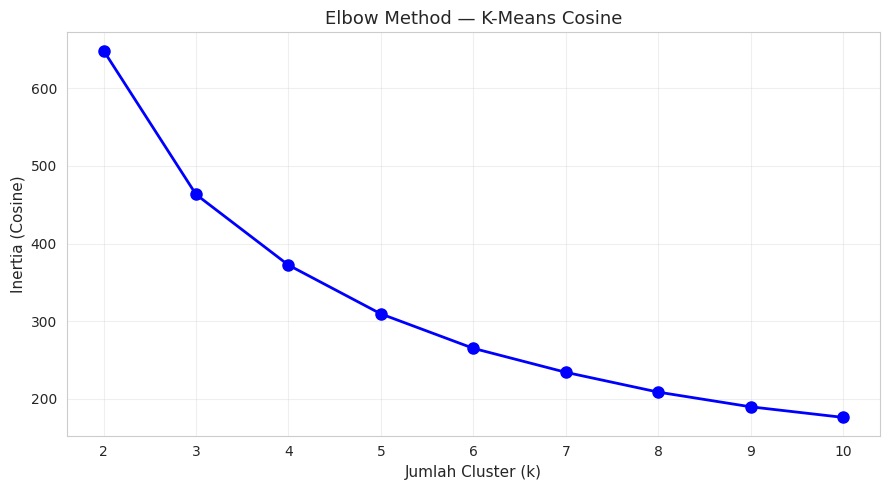

Inertia Cosine per k:
  k=2: 648.26
  k=3: 463.15
  k=4: 372.25
  k=5: 309.45
  k=6: 265.12
  k=7: 234.28
  k=8: 208.78
  k=9: 189.86
  k=10: 176.24


In [4]:
K_RANGE = range(2, 11)
inertia_cosine = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cosine)
    # Hitung inertia manual dengan cosine distance ke centroid
    dist_matrix = cosine_distances(X_cosine, km.cluster_centers_)
    labels_tmp = km.labels_
    inertia = sum(dist_matrix[i, labels_tmp[i]] for i in range(len(X_cosine)))
    inertia_cosine.append(inertia)

plt.figure(figsize=(9, 5))
plt.plot(K_RANGE, inertia_cosine, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)', fontsize=11)
plt.ylabel('Inertia (Cosine)', fontsize=11)
plt.title('Elbow Method — K-Means Cosine', fontsize=13)
plt.xticks(K_RANGE)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Inertia Cosine per k:")
for k, i in zip(K_RANGE, inertia_cosine):
    print(f"  k={k}: {i:.2f}")

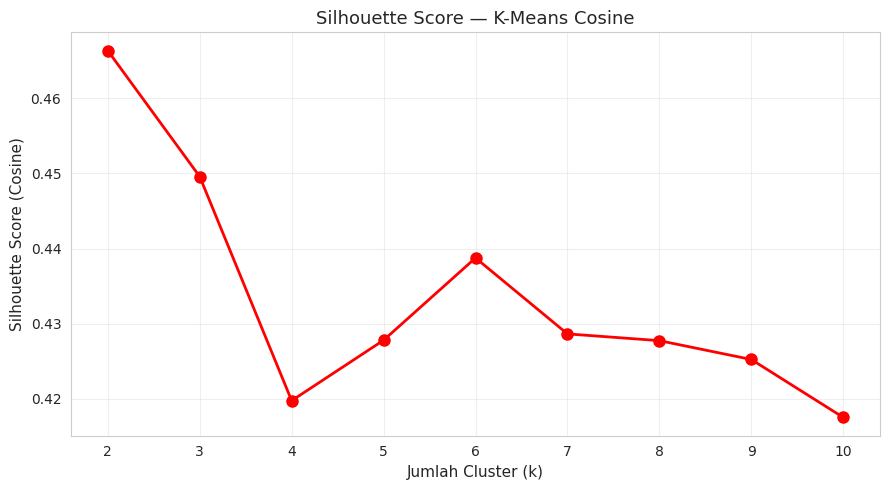

Silhouette Score per k:
  k=2: 0.4663
  k=3: 0.4496
  k=4: 0.4198
  k=5: 0.4278
  k=6: 0.4388
  k=7: 0.4287
  k=8: 0.4278
  k=9: 0.4253
  k=10: 0.4176

>> k dengan silhouette tertinggi: k=2


In [5]:
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km.fit_predict(X_cosine)
    score = silhouette_score(X_cosine, labels_tmp, metric='cosine')
    sil_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(K_RANGE, sil_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)', fontsize=11)
plt.ylabel('Silhouette Score (Cosine)', fontsize=11)
plt.title('Silhouette Score — K-Means Cosine', fontsize=13)
plt.xticks(K_RANGE)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Silhouette Score per k:")
for k, s in zip(K_RANGE, sil_scores):
    print(f"  k={k}: {s:.4f}")

print(f"\n>> k dengan silhouette tertinggi: k={list(K_RANGE)[np.argmax(sil_scores)]}")

In [6]:
# ============================================
# PARAMETER
# ============================================
K_OPTIMAL = 3

tracemalloc.start()
start_time = time.time()

# Training pada data yang sudah di-L2-normalize
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_cosine)

exec_time = time.time() - start_time
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

df['cluster'] = labels

# Inertia cosine final
dist_matrix = cosine_distances(X_cosine, kmeans.cluster_centers_)
inertia_final = sum(dist_matrix[i, labels[i]] for i in range(len(X_cosine)))

print("="*55)
print("HASIL K-MEANS (COSINE)")
print("="*55)
print(f"Jumlah cluster       : {K_OPTIMAL}")
print(f"Inertia Cosine       : {inertia_final:.4f}")
print(f"Waktu eksekusi       : {exec_time:.4f} detik")
print(f"Peak memory          : {peak/1024:.2f} KB")
print("\nDistribusi cluster:")
print(df['cluster'].value_counts().sort_index())

HASIL K-MEANS (COSINE)
Jumlah cluster       : 3
Inertia Cosine       : 463.1461
Waktu eksekusi       : 0.2754 detik
Peak memory          : 218.67 KB

Distribusi cluster:
cluster
0    464
1    574
2    460
Name: count, dtype: int64


In [7]:
print("Rata-rata fitur per cluster:")
print(df.groupby('cluster')[FEATURES].mean().round(2))

Rata-rata fitur per cluster:
         luas_m2  jumlah_kamar  jumlah_kamar_mandi  usia_bangunan  \
cluster                                                             
0          61.37          2.28                1.86          20.41   
1         119.54          4.39                3.89          19.43   
2         151.58          1.85                1.44          18.86   

                harga  
cluster                
0        6.055715e+08  
1        1.467735e+09  
2        1.715968e+09  


In [8]:
print("\nDistribusi lokasi per cluster:")
print(pd.crosstab(df['cluster'], df['lokasi']))

print("\nDistribusi kategori harga per cluster:")
print(pd.crosstab(df['cluster'], df['kategori_harga']))


Distribusi lokasi per cluster:
lokasi   Bekasi  Bogor  Depok  Jakarta Selatan  Jakarta Utara  Tangerang
cluster                                                                 
0            85    105     82               43             71         78
1           101    106     93               87             98         89
2            81     57     72               95             74         81

Distribusi kategori harga per cluster:
kategori_harga  Mahal  Murah
cluster                     
0                   9    455
1                 369    205
2                 371     89


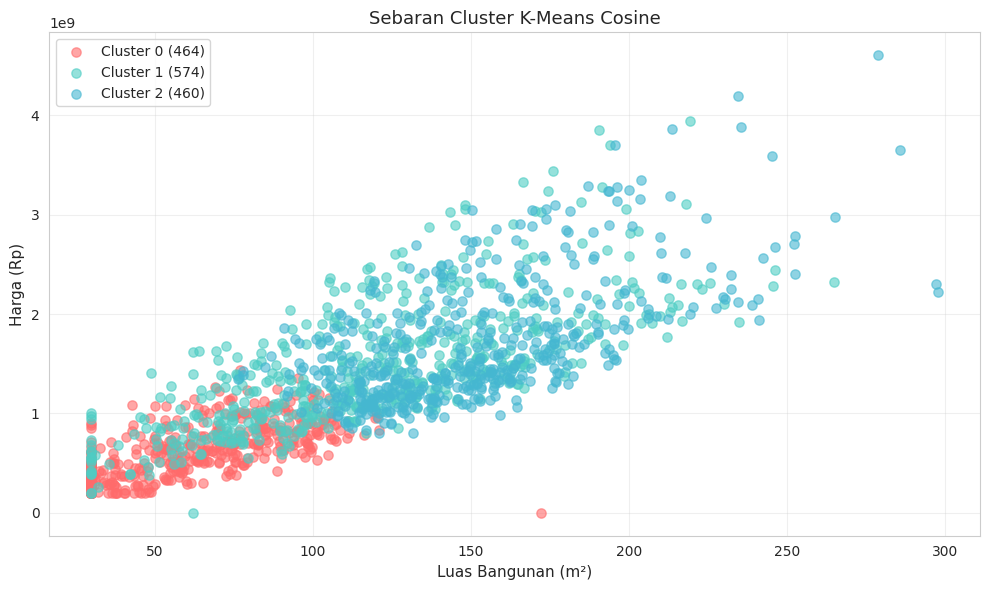

In [9]:
plt.figure(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
          '#DDA0DD', '#F0E68C', '#87CEEB', '#FFB6C1']

for i, label in enumerate(sorted(df['cluster'].unique())):
    subset = df[df['cluster'] == label]
    plt.scatter(subset['luas_m2'], subset['harga'],
                s=45, alpha=0.6, c=colors[i % len(colors)],
                label=f'Cluster {label} ({len(subset)})')

# Centroid (inverse dari L2 normalize tidak langsung bisa — jadi kita plot
# centroid dalam skala scaled tanpa inverse, atau skip centoid di cosine)
# Untuk cosine, centroid di scaled space sudah cukup sebagai referensi visual
plt.xlabel('Luas Bangunan (m²)', fontsize=11)
plt.ylabel('Harga (Rp)', fontsize=11)
plt.title('Sebaran Cluster K-Means Cosine', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

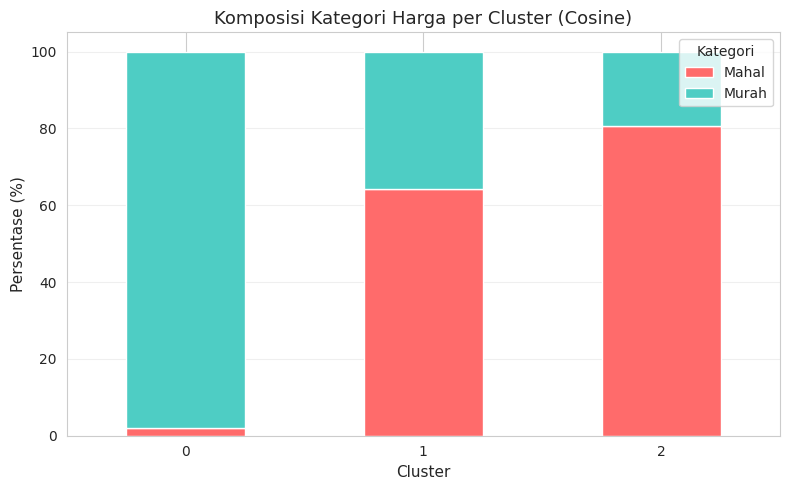


Persentase kategori harga per cluster (%):
kategori_harga  Mahal  Murah
cluster                     
0                1.94  98.06
1               64.29  35.71
2               80.65  19.35


In [10]:
comp = pd.crosstab(df['cluster'], df['kategori_harga'],
                   normalize='index') * 100

comp.plot(kind='bar', stacked=True, figsize=(8, 5),
          color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Persentase (%)', fontsize=11)
plt.title('Komposisi Kategori Harga per Cluster (Cosine)', fontsize=13)
plt.legend(title='Kategori', loc='upper right')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nPersentase kategori harga per cluster (%):")
print(comp.round(2))

In [11]:
sil_final = silhouette_score(X_cosine, df['cluster'], metric='cosine')
print(f"Silhouette Score Final (Cosine): {sil_final:.4f}")

Silhouette Score Final (Cosine): 0.4496


In [12]:
hasil_kmeans_cosine = {
    'Metode'              : 'K-Means',
    'Distance Metric'     : 'Cosine',
    'Jumlah Cluster'      : K_OPTIMAL,
    'Jumlah Noise'        : 0,
    'Waktu Eksekusi (s)'  : round(exec_time, 4),
    'Peak Memory (KB)'    : round(peak / 1024, 2),
    'Silhouette Score'    : round(sil_final, 4),
    'Parameter'           : f'k={K_OPTIMAL}'
}

tabel = pd.DataFrame([hasil_kmeans_cosine])
print("="*60)
print("RINGKASAN METRIK — K-MEANS COSINE")
print("="*60)
tabel.T

RINGKASAN METRIK — K-MEANS COSINE


,0
Metode,K-Means
Distance Metric,Cosine
Jumlah Cluster,3
Jumlah Noise,0
Waktu Eksekusi (s),0.2754
Peak Memory (KB),218.67
Silhouette Score,0.4496
Parameter,k=3
